# CBIM Problem Canvas

 Situation 

A multi specialty hospital collects patient data from different systems.
This includes registration, appointments, laboratory reports, wearable
devices, and doctor consultation notes.

Complication 

The data comes from different sources and may not be available in one
common format. The hospital needs a proper way to collect, clean,
combine, store, and analyze this data.

Question 

How can we design an end-to-end data engineering pipeline that combines
hospital data and makes it useful for operational and patient care analysis?

SSOT

The main source of truth will be the cleaned and integrated hospital
dataset stored in the analytical data layer.

Success Definition

The solution should successfully collect data from different sources,
clean the data, combine the information, and make it ready for analysis.

Primary Stakeholder

Hospital management and healthcare operations teams.

They need simple and reliable information about hospital operations and
patient conditions so they can make better decisions.

# Use Case Understanding

The hospital has data coming from many different systems.

For example, patient registration contains basic patient information,
the appointment system contains appointment details, laboratory reports
contain test results, wearable devices provide health readings, and
doctor consultations contain medical information.

The main idea of this project is to bring these different sources into
one simple data pipeline.

The pipeline will:

1. Collect the data.
2. Check and clean the data.
3. Combine related information.
4. Store the processed data.
5. Analyze the data.
6. Generate useful business insights.

This can help the hospital understand operational issues such as
waiting time and also support further analysis of patient risk.

#  Proposed Data Sources

The hospital will receive data from the following systems:

Patient Registration – Patient ID, age, gender

Appointment System – Appointment date, department, status

Laboratory Reports – Test name, test result

Wearable Devices – Heart rate, SpO2

Doctor Consultation – Diagnosis and consultation details

A common patient_id will be used to connect information belonging to the same patient.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### What I am doing

I am importing a few basic Python libraries that will help me create,
clean, combine, and analyze the hospital data.

I am keeping the implementation simple so that the complete pipeline
is easy to understand.

#  Create Sample Hospital Data

Since the assignment does not provide a real dataset, I will create
small sample datasets for this demonstration.

The sample data represents the type of information that could come
from different hospital systems.

In [2]:
patients = pd.DataFrame({
    "patient_id": [101, 102, 103, 104, 105, 106, 107, 108],
    "age": [25, 45, 62, 34, 71, 29, 55, 68],
    "gender": ["Male", "Female", "Male", "Female",
               "Male", "Female", "Male", "Female"]
})

patients

,patient_id,age,gender
0,101,25,Male
1,102,45,Female
2,103,62,Male
3,104,34,Female
4,105,71,Male
5,106,29,Female
6,107,55,Male
7,108,68,Female


In [3]:
appointments = pd.DataFrame({
    "patient_id": [101, 102, 103, 104, 105, 106, 107, 108],
    "department": [
        "Cardiology", "General Medicine", "Cardiology",
        "Orthopedics", "General Medicine", "Dermatology",
        "Cardiology", "Orthopedics"
    ],
    "appointment_time": [
        "09:00", "09:30", "10:00", "10:30",
        "11:00", "11:30", "12:00", "12:30"
    ],
    "consultation_time": [
        "09:20", "10:00", "10:45", "10:50",
        "11:40", "11:45", "12:40", "13:00"
    ]
})

appointments

,patient_id,department,appointment_time,consultation_time
0,101,Cardiology,09:00,09:20
1,102,General Medicine,09:30,10:00
2,103,Cardiology,10:00,10:45
3,104,Orthopedics,10:30,10:50
4,105,General Medicine,11:00,11:40
5,106,Dermatology,11:30,11:45
6,107,Cardiology,12:00,12:40
7,108,Orthopedics,12:30,13:00


### What I am doing

This dataset represents information from the hospital appointment system.

It contains the patient's department and the scheduled and actual
consultation times. These values will later help us understand
patient waiting time.

In [4]:
lab_reports = pd.DataFrame({
    "patient_id": [101, 102, 103, 104, 105, 106, 107, 108],
    "test_name": [
        "Blood Test", "Blood Test", "Blood Test", "Blood Test",
        "Blood Test", "Blood Test", "Blood Test", "Blood Test"
    ],
    "test_result": [95, 110, 145, 100, 160, 90, 135, 150]
})

lab_reports

,patient_id,test_name,test_result
0,101,Blood Test,95
1,102,Blood Test,110
2,103,Blood Test,145
3,104,Blood Test,100
4,105,Blood Test,160
5,106,Blood Test,90
6,107,Blood Test,135
7,108,Blood Test,150


In [5]:
wearable_data = pd.DataFrame({
    "patient_id": [101, 102, 103, 104, 105, 106, 107, 108],
    "heart_rate": [78, 82, 105, 76, 110, 72, 98, 108],
    "spo2": [98, 97, 94, 99, 92, 98, 95, 93]
})

wearable_data

,patient_id,heart_rate,spo2
0,101,78,98
1,102,82,97
2,103,105,94
3,104,76,99
4,105,110,92
5,106,72,98
6,107,98,95
7,108,108,93


In [6]:
consultations = pd.DataFrame({
    "patient_id": [101, 102, 103, 104, 105, 106, 107, 108],
    "diagnosis": [
        "Healthy",
        "Mild Fever",
        "High Blood Pressure",
        "Joint Pain",
        "Heart Risk",
        "Healthy",
        "Heart Risk",
        "Respiratory Risk"
    ]
})

consultations

,patient_id,diagnosis
0,101,Healthy
1,102,Mild Fever
2,103,High Blood Pressure
3,104,Joint Pain
4,105,Heart Risk
5,106,Healthy
6,107,Heart Risk
7,108,Respiratory Risk


# Step 1 — Load & Inspect


### What I am going to find

First, I will check the size and basic structure of the datasets.

This will help me understand whether the data is available in the
expected format before I start cleaning and combining it.

In [7]:
print("Patients:", patients.shape)
print("Appointments:", appointments.shape)
print("Lab Reports:", lab_reports.shape)
print("Wearable Data:", wearable_data.shape)
print("Consultations:", consultations.shape)

Patients: (8, 3)
Appointments: (8, 4)
Lab Reports: (8, 3)
Wearable Data: (8, 3)
Consultations: (8, 2)


### Business Insight

The hospital currently has separate datasets for different activities.

Each dataset contains patient-level information, but the information
is stored separately.

This shows why a data integration process is needed.

In [8]:
print("Patients")
print(patients.dtypes)

print("\nAppointments")
print(appointments.dtypes)

print("\nLab Reports")
print(lab_reports.dtypes)

print("\nWearable Data")
print(wearable_data.dtypes)

print("\nConsultations")
print(consultations.dtypes)

Patients
patient_id    int64
age           int64
gender          str
dtype: object

Appointments
patient_id           int64
department             str
appointment_time       str
consultation_time      str
dtype: object

Lab Reports
patient_id     int64
test_name        str
test_result    int64
dtype: object

Wearable Data
patient_id    int64
heart_rate    int64
spo2          int64
dtype: object

Consultations
patient_id    int64
diagnosis       str
dtype: object


In [9]:
print("Patients missing values:")
print(patients.isnull().sum())

print("\nAppointments missing values:")
print(appointments.isnull().sum())

print("\nLab Reports missing values:")
print(lab_reports.isnull().sum())

print("\nWearable data missing values:")
print(wearable_data.isnull().sum())

print("\nConsultations missing values:")
print(consultations.isnull().sum())

Patients missing values:
patient_id    0
age           0
gender        0
dtype: int64

Appointments missing values:
patient_id           0
department           0
appointment_time     0
consultation_time    0
dtype: int64

Lab Reports missing values:
patient_id     0
test_name      0
test_result    0
dtype: int64

Wearable data missing values:
patient_id    0
heart_rate    0
spo2          0
dtype: int64

Consultations missing values:
patient_id    0
diagnosis     0
dtype: int64


### Business Insight

The sample datasets do not contain major missing values.

This means the data can move to the next stage without requiring
major missing-value treatment for this demonstration.

In a real hospital system, missing or incorrect medical information
would need to be handled carefully.

In [10]:
print("Duplicate patients:", patients.duplicated().sum())
print("Duplicate appointments:", appointments.duplicated().sum())
print("Duplicate lab records:", lab_reports.duplicated().sum())
print("Duplicate wearable records:", wearable_data.duplicated().sum())
print("Duplicate consultations:", consultations.duplicated().sum())

Duplicate patients: 0
Duplicate appointments: 0
Duplicate lab records: 0
Duplicate wearable records: 0
Duplicate consultations: 0


### Business Insight

The sample data does not contain duplicate records.

Checking duplicates is important because duplicate patient or
appointment records could affect the final analysis.

#  Step 2 — Data Ingestion

**Built by:** Pratyush Kumar Pandey

### What I am going to find

In this step, I will represent how data from different hospital
systems enters the data engineering pipeline.

The five sources are:

- Patient Registration
- Appointment System
- Laboratory Reports
- Wearable Devices
- Doctor Consultation

For this notebook, the data is already available as pandas DataFrames.
In a real system, these sources could be connected through files,
databases, APIs, or streaming systems.

In [11]:
data_sources = {
    "Patient Registration": patients,
    "Appointments": appointments,
    "Laboratory Reports": lab_reports,
    "Wearable Data": wearable_data,
    "Consultations": consultations
}

for name, data in data_sources.items():
    print(name, ":", data.shape)

Patient Registration : (8, 3)
Appointments : (8, 4)
Laboratory Reports : (8, 3)
Wearable Data : (8, 3)
Consultations : (8, 2)


### Business Insight

The hospital data is coming from different systems.

The next important step is to clean and standardize these datasets
before combining them.

#  Step 3 — Data Cleaning

**Built by:** Pratyush Kumar Pandey

### What I am going to find

Before combining the data, I will make sure that the important fields
are in the correct format.

I will mainly:

- Remove duplicate records.
- Convert time values into a usable format.
- Check missing values.
- Keep the patient ID consistent across datasets.

In [12]:
patients = patients.drop_duplicates()
appointments = appointments.drop_duplicates()
lab_reports = lab_reports.drop_duplicates()
wearable_data = wearable_data.drop_duplicates()
consultations = consultations.drop_duplicates()

print("Cleaning completed.")

Cleaning completed.


In [13]:
appointments["appointment_time"] = pd.to_datetime(
    appointments["appointment_time"],
    format="%H:%M"
)

appointments["consultation_time"] = pd.to_datetime(
    appointments["consultation_time"],
    format="%H:%M"
)

appointments.head()

,patient_id,department,appointment_time,consultation_time
0,101,Cardiology,1900-01-01 09:00:00,1900-01-01 09:20:00
1,102,General Medicine,1900-01-01 09:30:00,1900-01-01 10:00:00
2,103,Cardiology,1900-01-01 10:00:00,1900-01-01 10:45:00
3,104,Orthopedics,1900-01-01 10:30:00,1900-01-01 10:50:00
4,105,General Medicine,1900-01-01 11:00:00,1900-01-01 11:40:00


### Business Insight

The appointment and consultation times are now stored in a format
that can be used for calculations.

This is important because we need these values later to calculate
patient waiting time.

In [14]:
appointments["waiting_minutes"] = (
    appointments["consultation_time"] -
    appointments["appointment_time"]
).dt.total_seconds() / 60

appointments

,patient_id,department,appointment_time,consultation_time,waiting_minutes
0,101,Cardiology,1900-01-01 09:00:00,1900-01-01 09:20:00,20.0
1,102,General Medicine,1900-01-01 09:30:00,1900-01-01 10:00:00,30.0
2,103,Cardiology,1900-01-01 10:00:00,1900-01-01 10:45:00,45.0
3,104,Orthopedics,1900-01-01 10:30:00,1900-01-01 10:50:00,20.0
4,105,General Medicine,1900-01-01 11:00:00,1900-01-01 11:40:00,40.0
5,106,Dermatology,1900-01-01 11:30:00,1900-01-01 11:45:00,15.0
6,107,Cardiology,1900-01-01 12:00:00,1900-01-01 12:40:00,40.0
7,108,Orthopedics,1900-01-01 12:30:00,1900-01-01 13:00:00,30.0


### Business Insight

The waiting time is now available for every patient.

This creates a useful operational metric for the hospital because
management can identify departments or periods where patients
are waiting longer than expected.

#  Step 4 — Data Integration

**Built by:** Pratyush Kumar Pandey

### What I am going to find

The hospital information is currently separated across different
datasets.

I will now combine the datasets using `patient_id`.

This will create one integrated dataset that contains patient,
appointment, laboratory, wearable, and consultation information.

In [15]:
integrated_data = patients.merge(
    appointments,
    on="patient_id",
    how="left"
)

integrated_data.head()

,patient_id,age,gender,department,appointment_time,consultation_time,waiting_minutes
0,101,25,Male,Cardiology,1900-01-01 09:00:00,1900-01-01 09:20:00,20.0
1,102,45,Female,General Medicine,1900-01-01 09:30:00,1900-01-01 10:00:00,30.0
2,103,62,Male,Cardiology,1900-01-01 10:00:00,1900-01-01 10:45:00,45.0
3,104,34,Female,Orthopedics,1900-01-01 10:30:00,1900-01-01 10:50:00,20.0
4,105,71,Male,General Medicine,1900-01-01 11:00:00,1900-01-01 11:40:00,40.0


In [16]:
integrated_data = integrated_data.merge(
    lab_reports,
    on="patient_id",
    how="left"
)

integrated_data.head()

,patient_id,age,gender,department,appointment_time,consultation_time,waiting_minutes,test_name,test_result
0,101,25,Male,Cardiology,1900-01-01 09:00:00,1900-01-01 09:20:00,20.0,Blood Test,95
1,102,45,Female,General Medicine,1900-01-01 09:30:00,1900-01-01 10:00:00,30.0,Blood Test,110
2,103,62,Male,Cardiology,1900-01-01 10:00:00,1900-01-01 10:45:00,45.0,Blood Test,145
3,104,34,Female,Orthopedics,1900-01-01 10:30:00,1900-01-01 10:50:00,20.0,Blood Test,100
4,105,71,Male,General Medicine,1900-01-01 11:00:00,1900-01-01 11:40:00,40.0,Blood Test,160


In [17]:
integrated_data = integrated_data.merge(
    wearable_data,
    on="patient_id",
    how="left"
)

integrated_data.head()

,patient_id,age,gender,department,appointment_time,consultation_time,waiting_minutes,test_name,test_result,heart_rate,spo2
0,101,25,Male,Cardiology,1900-01-01 09:00:00,1900-01-01 09:20:00,20.0,Blood Test,95,78,98
1,102,45,Female,General Medicine,1900-01-01 09:30:00,1900-01-01 10:00:00,30.0,Blood Test,110,82,97
2,103,62,Male,Cardiology,1900-01-01 10:00:00,1900-01-01 10:45:00,45.0,Blood Test,145,105,94
3,104,34,Female,Orthopedics,1900-01-01 10:30:00,1900-01-01 10:50:00,20.0,Blood Test,100,76,99
4,105,71,Male,General Medicine,1900-01-01 11:00:00,1900-01-01 11:40:00,40.0,Blood Test,160,110,92


In [18]:
integrated_data = integrated_data.merge(
    consultations,
    on="patient_id",
    how="left"
)

integrated_data

,patient_id,age,gender,department,appointment_time,consultation_time,waiting_minutes,test_name,test_result,heart_rate,spo2,diagnosis
0,101,25,Male,Cardiology,1900-01-01 09:00:00,1900-01-01 09:20:00,20.0,Blood Test,95,78,98,Healthy
1,102,45,Female,General Medicine,1900-01-01 09:30:00,1900-01-01 10:00:00,30.0,Blood Test,110,82,97,Mild Fever
2,103,62,Male,Cardiology,1900-01-01 10:00:00,1900-01-01 10:45:00,45.0,Blood Test,145,105,94,High Blood Pressure
3,104,34,Female,Orthopedics,1900-01-01 10:30:00,1900-01-01 10:50:00,20.0,Blood Test,100,76,99,Joint Pain
4,105,71,Male,General Medicine,1900-01-01 11:00:00,1900-01-01 11:40:00,40.0,Blood Test,160,110,92,Heart Risk
5,106,29,Female,Dermatology,1900-01-01 11:30:00,1900-01-01 11:45:00,15.0,Blood Test,90,72,98,Healthy
6,107,55,Male,Cardiology,1900-01-01 12:00:00,1900-01-01 12:40:00,40.0,Blood Test,135,98,95,Heart Risk
7,108,68,Female,Orthopedics,1900-01-01 12:30:00,1900-01-01 13:00:00,30.0,Blood Test,150,108,93,Respiratory Risk


In [19]:
print("Integrated dataset shape:", integrated_data.shape)

integrated_data.head()

Integrated dataset shape: (8, 12)


,patient_id,age,gender,department,appointment_time,consultation_time,waiting_minutes,test_name,test_result,heart_rate,spo2,diagnosis
0,101,25,Male,Cardiology,1900-01-01 09:00:00,1900-01-01 09:20:00,20.0,Blood Test,95,78,98,Healthy
1,102,45,Female,General Medicine,1900-01-01 09:30:00,1900-01-01 10:00:00,30.0,Blood Test,110,82,97,Mild Fever
2,103,62,Male,Cardiology,1900-01-01 10:00:00,1900-01-01 10:45:00,45.0,Blood Test,145,105,94,High Blood Pressure
3,104,34,Female,Orthopedics,1900-01-01 10:30:00,1900-01-01 10:50:00,20.0,Blood Test,100,76,99,Joint Pain
4,105,71,Male,General Medicine,1900-01-01 11:00:00,1900-01-01 11:40:00,40.0,Blood Test,160,110,92,Heart Risk


### Business Insight

The separate hospital datasets have now been combined using
`patient_id`.

The integrated dataset gives us a more complete view of each patient.

This makes it easier to connect operational information such as
waiting time with laboratory, wearable, and consultation information.

#  Step 5 — Data Storage Design


### What I am going to find

After collecting and processing the data, the hospital needs a place
to store it in an organized way.

A simple proposed architecture is:

Hospital Systems

        ↓

Data Ingestion

        ↓

Raw Data Layer

        ↓

Data Cleaning & Processing

        ↓

Cleaned Data Layer

        ↓

Analytical Data Store

        ↓

Reports and Analytics

The raw layer keeps the original data.

The cleaned layer contains standardized and processed data.

The analytical layer contains data that is ready for business analysis.

In [20]:
integrated_data.to_csv(
    "hospital_integrated_data.csv",
    index=False
)

print("Integrated data saved successfully.")

Integrated data saved successfully.


### Business Insight

The integrated dataset has been saved as a processed data file.

In a real hospital environment, this layer could be stored in a
database, data warehouse, or cloud storage system instead of a local CSV file.

#  Step 6 — Main Analysis: Patient Waiting Time


### What I am going to find

I will analyze patient waiting time to understand the operational
performance of the hospital.

Waiting time is calculated as the difference between the scheduled
appointment time and the actual consultation time.

In [21]:
average_waiting_time = integrated_data["waiting_minutes"].mean()

print("Average patient waiting time:",
      round(average_waiting_time, 2), "minutes")

Average patient waiting time: 30.0 minutes


### Business Insight

The average waiting time gives the hospital a simple measure of
how long patients are waiting before consultation.

Management can use this metric as a starting point for improving
appointment scheduling and hospital operations.

In [22]:
department_waiting = (
    integrated_data
    .groupby("department")["waiting_minutes"]
    .mean()
    .sort_values(ascending=False)
)

department_waiting

department
Cardiology          35.0
General Medicine    35.0
Orthopedics         25.0
Dermatology         15.0
Name: waiting_minutes, dtype: float64

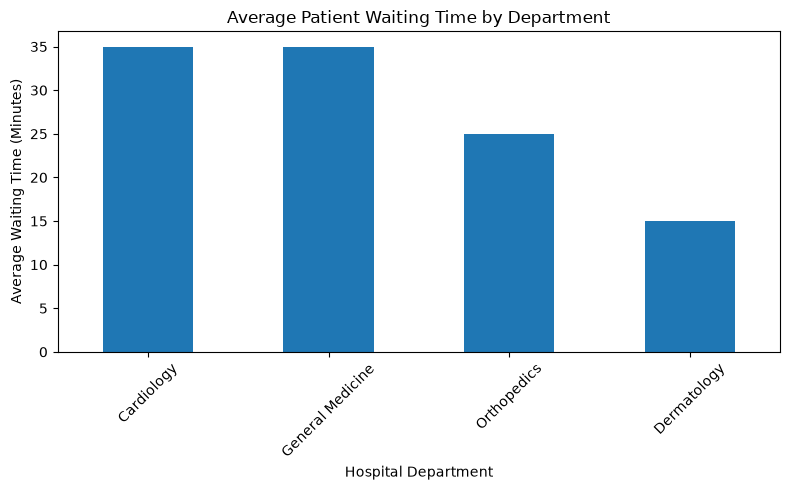

In [23]:
department_waiting.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Patient Waiting Time by Department")
plt.xlabel("Hospital Department")
plt.ylabel("Average Waiting Time (Minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Business Insight

The chart shows the average waiting time for each department.

Departments with higher waiting times may need a closer review of
appointment scheduling, doctor availability, or patient flow.

The hospital can use this information to identify where operational
improvements may be needed.

#  Step 7 — Detailed Patient Analysis

**Built by:** Pratyush Kumar Pandey

### What I am going to find

I will look at individual patient information to identify patients
who have multiple values that may require additional attention.

This is only a demonstration using sample data. It is not a medical
diagnosis or a clinical decision-making system.

In [24]:
integrated_data["risk_score"] = (
    (integrated_data["age"] >= 60).astype(int)
    + (integrated_data["heart_rate"] >= 100).astype(int)
    + (integrated_data["spo2"] < 95).astype(int)
    + (integrated_data["test_result"] >= 130).astype(int)
)

integrated_data[
    ["patient_id", "age", "heart_rate", "spo2",
     "test_result", "risk_score", "diagnosis"]
]

,patient_id,age,heart_rate,spo2,test_result,risk_score,diagnosis
0,101,25,78,98,95,0,Healthy
1,102,45,82,97,110,0,Mild Fever
2,103,62,105,94,145,4,High Blood Pressure
3,104,34,76,99,100,0,Joint Pain
4,105,71,110,92,160,4,Heart Risk
5,106,29,72,98,90,0,Healthy
6,107,55,98,95,135,1,Heart Risk
7,108,68,108,93,150,4,Respiratory Risk


In [25]:
def risk_category(score):
    if score >= 3:
        return "High Attention"
    elif score == 2:
        return "Medium Attention"
    else:
        return "Low Attention"

integrated_data["risk_category"] = (
    integrated_data["risk_score"].apply(risk_category)
)

integrated_data[
    ["patient_id", "risk_score", "risk_category"]
]

,patient_id,risk_score,risk_category
0,101,0,Low Attention
1,102,0,Low Attention
2,103,4,High Attention
3,104,0,Low Attention
4,105,4,High Attention
5,106,0,Low Attention
6,107,1,Low Attention
7,108,4,High Attention


In [26]:
risk_summary = (
    integrated_data["risk_category"]
    .value_counts()
)

risk_summary

risk_category
Low Attention     5
High Attention    3
Name: count, dtype: int64

### Business Insight

The sample risk score helps demonstrate how information from different
sources can be brought together for further analysis.

For example, age, wearable readings, laboratory results, and consultation
information can be considered together.

This is only a technical demonstration. The sample risk score should
not be used for real medical decisions.

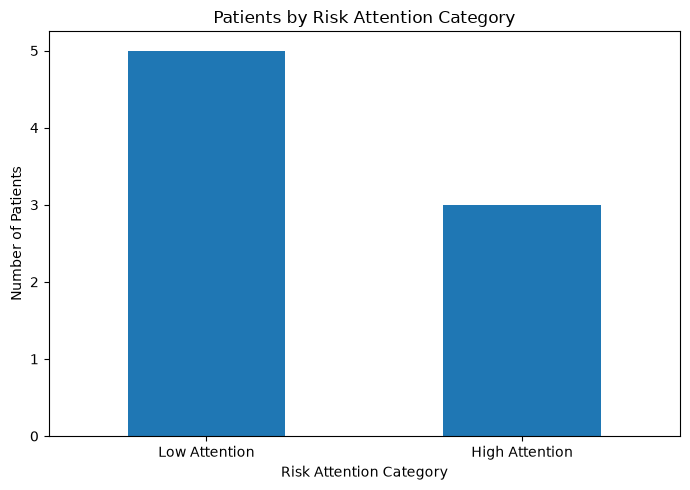

In [27]:
risk_summary.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Patients by Risk Attention Category")
plt.xlabel("Risk Attention Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#  Step 8 —  Comparison Analysis


### What I am going to find

I will compare the waiting time across different hospital departments.

This will help us understand whether some departments have a higher
operational waiting-time problem than others.

In [28]:
department_summary = (
    integrated_data
    .groupby("department")
    .agg(
        patients=("patient_id", "count"),
        average_waiting_time=("waiting_minutes", "mean")
    )
    .sort_values(
        "average_waiting_time",
        ascending=False
    )
)

department_summary

,patients,average_waiting_time
department,,
Cardiology,3,35.0
General Medicine,2,35.0
Orthopedics,2,25.0
Dermatology,1,15.0


### Business Insight

The comparison shows that waiting time is not the same across all
departments.

The department with the highest average waiting time should be reviewed
first to understand whether scheduling or patient flow is causing delays.

This does not mean that the department is performing poorly overall.
It only shows that its waiting time deserves further investigation.

#  Step 9 — Time and Pattern Analysis


### What I am going to find

I will compare patient waiting time across appointment time periods.

This can help us understand whether waiting time changes during
different parts of the day.

In [29]:
integrated_data["appointment_hour"] = (
    integrated_data["appointment_time"].dt.hour
)

integrated_data[
    ["patient_id", "appointment_time", "waiting_minutes"]
]

,patient_id,appointment_time,waiting_minutes
0,101,1900-01-01 09:00:00,20.0
1,102,1900-01-01 09:30:00,30.0
2,103,1900-01-01 10:00:00,45.0
3,104,1900-01-01 10:30:00,20.0
4,105,1900-01-01 11:00:00,40.0
5,106,1900-01-01 11:30:00,15.0
6,107,1900-01-01 12:00:00,40.0
7,108,1900-01-01 12:30:00,30.0


In [30]:
time_summary = (
    integrated_data
    .groupby("appointment_hour")["waiting_minutes"]
    .mean()
)

time_summary

appointment_hour
9     25.0
10    32.5
11    27.5
12    35.0
Name: waiting_minutes, dtype: float64

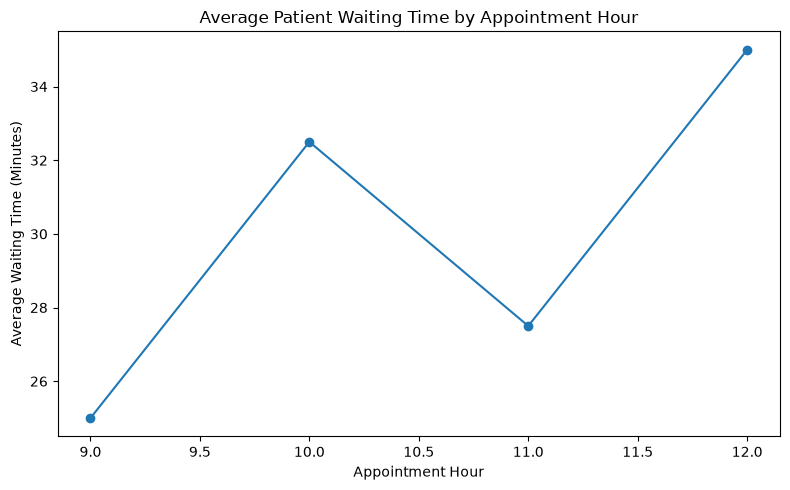

In [31]:
time_summary.plot(
    kind="line",
    marker="o",
    figsize=(8, 5)
)

plt.title("Average Patient Waiting Time by Appointment Hour")
plt.xlabel("Appointment Hour")
plt.ylabel("Average Waiting Time (Minutes)")
plt.tight_layout()
plt.show()

### Business Insight

The time analysis shows how waiting time changes during the appointment
hours available in the sample data.

If a similar pattern appears in real hospital data, management can use
it to plan doctor availability, appointment slots, and patient flow
during busy periods.

In [32]:
best_department = department_summary[
    "average_waiting_time"
].idxmin()

worst_department = department_summary[
    "average_waiting_time"
].idxmax()

print("Lowest average waiting time:", best_department)
print("Highest average waiting time:", worst_department)

Lowest average waiting time: Dermatology
Highest average waiting time: Cardiology


### Business Insight

The comparison identifies the departments with the lowest and highest
average waiting times in the sample.

The department with the highest waiting time can be reviewed further
to understand the reason for the delay.

The department with the lowest waiting time can also be studied to
understand whether its process can be used as a reference for other
departments.

#  Step 10 — Final Business Briefing


The proposed hospital data engineering pipeline brings data from
patient registration, appointments, laboratory reports, wearable
devices, and consultations into one integrated dataset. The analysis
shows how the processed data can be used to understand patient waiting
time across departments. The combined data can also support further
patient-risk analysis by bringing different patient indicators together.
The hospital should use this pipeline as a foundation for monitoring
operational performance and identifying areas that need further review.
In a real implementation, the sample data should be replaced with
validated hospital data and appropriate security controls.

#  Final Business Insights

### Insight 1 — Data Integration

The hospital has data from several different systems.

**Meaning:**  
Keeping these sources separate makes it harder to get one complete
view of a patient.

**Action:**  
Use a common patient ID and an integrated data pipeline to connect
the information.

---

### Insight 2 — Waiting Time

The integrated data allows us to calculate patient waiting time.

**Meaning:**  
Management can identify departments where patients may be waiting
longer.

**Action:**  
Review high-waiting departments and check appointment scheduling
and patient flow.

---

### Insight 3 — Patient Risk Analysis

The pipeline can bring laboratory and wearable information together.

**Meaning:**  
Multiple data sources can be used for further patient-risk analysis.

**Action:**  
Use validated clinical rules and real hospital data before using
any risk model for actual healthcare decisions.

---

### Insight 4 — Data Engineering Foundation

The pipeline creates a common flow from data collection to analysis.

**Meaning:**  
The hospital can build future dashboards, reports, and analytical
solutions on top of the processed data.

**Action:**  
Move from the sample pipeline to a secure production data platform
when real hospital data becomes available.

#  Proposed End-to-End Data Engineering Architecture

The complete solution can be represented as:

Hospital Data Sources
        ↓
Data Ingestion
        ↓
Raw Data Layer
        ↓
Data Cleaning and Processing
        ↓
Data Integration
        ↓
Curated Data Layer
        ↓
Analytical Data Store
        ↓
Analytics and Reporting
        ↓
Hospital Management

### Main Components

**1. Data Sources**  
Patient registration, appointments, laboratory systems, wearable devices,
and doctor consultation systems.

**2. Data Ingestion**  
Collect data from the different hospital systems.

**3. Raw Data Layer**  
Keep the original incoming data before major transformations.

**4. Processing Layer**  
Clean, validate, standardize, and transform the data.

**5. Integration Layer**  
Connect patient information using a common patient identifier.

**6. Analytical Data Store**  
Store processed data in a form that is easy to analyze.

**7. Analytics Layer**  
Use the processed data for waiting-time analysis, patient monitoring,
reporting, and future predictive analytics.

#  Limitations

This notebook is a demonstration of the proposed data engineering
solution.

The main limitations are:

1. The assignment does not provide a real hospital dataset.
2. The data used in this notebook is sample data.
3. The risk score is only a demonstration and is not a medical model.
4. A real hospital system would require stronger security and privacy controls.
5. A production system would require proper databases, APIs, monitoring,
   access control, and data validation.

#  Final Recommendation

The hospital should build a centralized data engineering pipeline that
can collect information from its different systems and convert it into
clean and integrated data.

The first focus should be reliable data ingestion, cleaning, and
integration because good analysis depends on good-quality data.

After that, the hospital can build dashboards and analytical solutions
for waiting time, patient operations, and patient-risk monitoring.

The sample notebook demonstrates the basic flow that can later be
expanded into a real production data platform.

# Final Summary

## Key Findings

1. The hospital receives data from multiple systems.
2. These sources need to be collected and processed through a common pipeline.
3. The datasets can be connected using a common `patient_id`.
4. The integrated data can be used to analyze patient waiting time.
5. The combined information can also support further patient-risk analysis.

## Recommendation

The hospital should use a layered data engineering architecture with
data ingestion, raw storage, processing, integration, analytical
storage, and analytics.

## Limitation

The assignment does not provide a real dataset, so sample data was used
to demonstrate the solution.

## Business Value

The proposed pipeline can help the hospital move from separate data
sources to a more organized and useful data environment.
